In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

# Two-sheet covering

Let's explore the two-sheet covering of the Klein bottle by the torus.

(See the Geogebra `.ggb` file for a visualisation and details)

Following this [question on Math.Stackexchange](https://math.stackexchange.com/questions/1073425/two-sheeted-covering-of-the-klein-bottle-by-the-torus), given a torus as a $[0,1]^2$ square with proper gluing of the sides,
we identify (glue) any two points $A$ and $B$ on a torus with such coordinates:

$A(x,y)\sim B\big(1-x, (y+\frac{1}{2}) \text{ mod } 1\big)$

So one should find such a mapping $f()$ that $f(A)=f(B)$ for any two such points. One such mapping is:

$$f_x(x,y) = \begin{cases}
2x, \text{  if  }0\leq x\leq1/2 \\
2-2x, \text{  if  }1/2< x\leq1
\end{cases} \\
f_y(x,y) = \begin{cases}
2y, \text{  if  }0\leq y\leq1/2 \\
2y-1, \text{  if  }1/2< y\leq1
\end{cases} 
$$

Let's play with it a bit:

In [ ]:
def cover(points):
    """
    points is of shape = (n_points, 2)
    """
    xs, ys = points[:,0], points[:,1]
    xs_K, ys_K = [], []
    for i in range(points.shape[0]):
        x, y = xs[i], ys[i]
        xs_K.append(2*x if x <= 0.5 else 2-2*x)
        ys_K.append(2*y if y <= 0.5 else 2*y-1)
    return np.array([xs_K,ys_K]).T

In [ ]:
fig = plt.figure(figsize=(4,2))
ax = fig.subplots(1,2)

for i in [0,1]:
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].axes.get_xaxis().set_ticks([0,1])
    ax[i].axes.get_yaxis().set_ticks([0,1])

    
points = np.array([[0.2,0.2],
         [0.3,0.2],
         [0.2,0.3],
         [0.3,0.3]])


ax[0].scatter(points[:,0],points[:,1])

covers = cover(points)

ax[1].scatter(covers[:,0],covers[:,1])

In [ ]:
x1 = np.random.multivariate_normal(mean=np.array([0.5,0.5]), 
                                   cov=np.array([[1,0],[0,1]]),
                                  size=100)

In [ ]:
fig = plt.figure(figsize=(4,2))
ax = fig.subplots(1,2)

for i in [0,1]:
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].axes.get_xaxis().set_ticks([0,1])
    ax[i].axes.get_yaxis().set_ticks([0,1])

    
points = np.random.multivariate_normal(mean=np.array([0.75,0.75]), 
                                   cov=np.array([[0.01,0],[0,0.01]]),
                                  size=200)

points = points % 1


angles = np.linspace(0,2*np.pi,200)
circle = np.array([np.cos(angles), np.sin(angles)]).T * 0.1
circle += 0.75

ax[0].scatter(points[:,0],points[:,1],s=0.4,color='blue')
ax[0].scatter(circle[:,0],circle[:,1],s=0.3,color='blue')

covers = cover(points)

c_circle = cover(circle)

ax[1].scatter(covers[:,0],covers[:,1],s=0.4,color='blue')
ax[1].scatter(c_circle[:,0],c_circle[:,1],s=0.3,color='blue')

In [ ]:
circle

# My Covering

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ripser import ripser 
from persim import plot_diagrams

In [2]:
a = 3
b = 4

def double_covering(x, y):
    """
    Applies the double covering map to arrays x and y.
    Supports numpy arrays (and later torch tensors).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = x <= 0.5
    u = np.where(mask, 2 * x, 2 * x - 1)
    v = np.where(mask, y, 1 - y)
    return u, v

#https://www.mathcurve.com/surfaces.gb/klein/klein.shtml
def projection(u,v):
    return (
        (a + b * np.cos(v)) * np.cos(u),
        (a + b * np.cos(v)) * np.sin(u),
        (b * np.sin(v)) * np.cos(u/2),
        (b * np.sin(v)) * np.sin(u/2),
    )

So `double_covering` and `projection` returns a point in $\R^4$ on the surface of Klein bottle. Now if we are able to sample a point from a torus, we can therefore do what we need.

Check https://mathoverflow.net/a/484137/130473 for tests

In [ ]:
random_x = np.random.normal(0, 1, (1,))
random_y = np.random.normal(0, 1, (1,))

u,v=double_covering(random_x, random_y)
x,y,z,t = projection(u,v)

In [ ]:
assert np.isclose(4*a**2*(x**2 + y**2), (a**2 - b**2 + x**2 + y**2 + z**2 + t**2)**2)
assert np.isclose(y * (z**2 - t**2), 2 * x * z * t)
assert x * (z**2 - t**2) >= 0
assert y * z * t >= 0

In [ ]:
num_points = 1_000
random_xs = np.random.normal(0, 1, (num_points,))
random_ys = np.random.normal(0, 1, (num_points,))

us, vs = double_covering(random_xs, random_ys)
xs, ys, zs, ts = projection(us, vs)
points = np.stack([xs, ys, zs, ts], axis=1)

points.shape

In [ ]:
%%time

diagrams2 = ripser(points, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(points, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(30, 12))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

In [ ]:
lifespan_of_1cycles = sorted([d - b for b,d in diagrams2[1]], reverse=True)
lifespan_of_1cycles[:10]

# Another attempt

(20000, 2)
Preimage of point [1.5 6. ] on Torus:
 [[1.5        6.        ]
 [4.64159265 0.28318531]]
Preimage of point [[1.5        6.        ]
 [4.64159265 0.28318531]] on Plane:
 [[-4.78318531 -0.28318531]
 [-1.64159265 -6.        ]
 [-4.78318531  6.        ]
 [-1.64159265  0.28318531]
 [-4.78318531 12.28318531]
 [-1.64159265  6.56637061]
 [ 1.5        -0.28318531]
 [ 4.64159265 -6.        ]
 [ 1.5         6.        ]
 [ 4.64159265  0.28318531]
 [ 1.5        12.28318531]
 [ 4.64159265  6.56637061]
 [ 7.78318531 -0.28318531]
 [10.92477796 -6.        ]
 [ 7.78318531  6.        ]
 [10.92477796  0.28318531]
 [ 7.78318531 12.28318531]
 [10.92477796  6.56637061]]


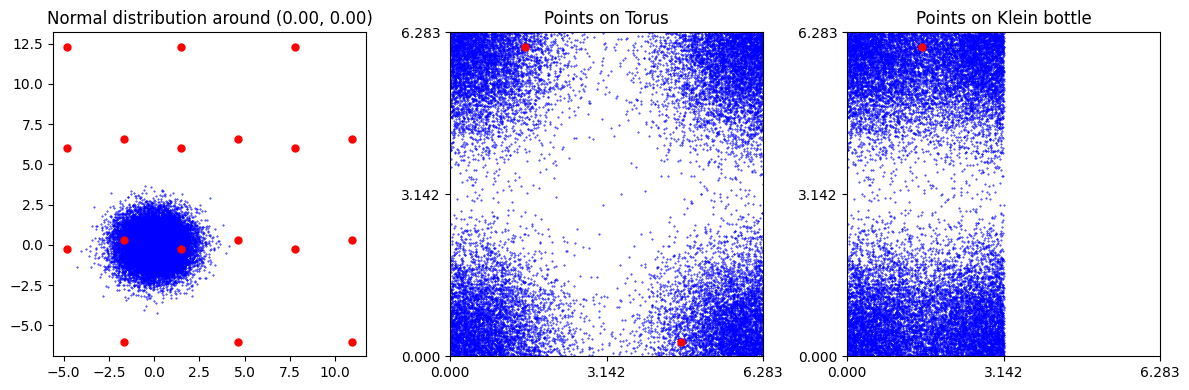

In [9]:
def project_klein(theta1, theta2, eps=1e-3):
    """
    Project any (theta1, theta2) in R^2 onto the canonical
    fundamental domain D = [0, 2π) × [0, π) for the Klein bottle, using:

        1) (theta1, theta2) ~ (theta1 + 2pi k, theta2 + 2pi l)     for k,l in Z
        2) (theta1, theta2) ~ (theta1 + pi, -theta2)               (the flip relation)

    Steps:
      a) Reduce theta1 mod 2pi  → u in [0, 2pi),
      b) Reduce theta2 mod 2pi  → v in [0, 2pi),
      c) If u > pi, fold u -> u - pi and v -> -v mod 2pi.
    """

    # u and v are the points on torus T^2
    u = np.remainder(theta1, 2 * np.pi)
    v = np.remainder(theta2, 2 * np.pi)

    u_mask = (u >= np.pi)
    u[u_mask] = u[u_mask] - np.pi
    v[u_mask] = np.remainder(- v[u_mask], 2 * np.pi)
    
    return np.stack([u, v], axis=1)    

def preimage_of_klein(points):
    """
    Given points in the Klein bottle, return its 2 preimages on Torus T^2.
    """
    xs, ys = points[:,0], points[:,1]
    xs_unflipped = np.where(xs < np.pi, xs + np.pi, xs)
    ys_unflipped = np.remainder(np.where(xs < np.pi, -ys, ys), 2 * np.pi)
    xs_plane = np.stack([xs, xs_unflipped], axis=1).flatten()
    ys_plane = np.stack([ys, ys_unflipped], axis=1).flatten()
    return np.array([xs_plane, ys_plane]).T

def preimage_of_torus_grid(points, grid_size=1):
    xs, ys = points[:, 0], points[:, 1]
    shifts = range(-grid_size, grid_size + 1)
    all_preimages = [
        np.column_stack([xs + 2*np.pi*i, ys + 2*np.pi*j])
        for i in shifts
        for j in shifts
    ]
    return np.concatenate(all_preimages, axis=0)

def preimage_of_torus_recursive(points, aux=0):
    grid = 2 * np.pi * np.linspace(-1,1,3)
    meshgrid = np.meshgrid(grid, grid, indexing='ij')
    meshgrid_points = np.column_stack([meshgrid[0].flatten(), meshgrid[1].flatten()])
    preimages = np.array([meshgrid_points + point for point in points]).reshape(-1, 2)
    if aux > 0:
        return preimage_of_torus_recursive(preimages, aux=aux-1)
    else:
        return preimages
    

# Example usage

mean=np.array([0, 0])
cov=np.array([[1, 0], [0, 1]])

np.random.seed(28)

points = np.random.multivariate_normal(mean=mean, cov=cov, size=20000)
print(points.shape)
klein_points = project_klein(points[:,0], points[:,1])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title(f'Normal distribution around ({mean[0]:.2f}, {mean[1]:.2f})')

axes[1].plot(np.remainder(points[:,0], 2 * np.pi), np.remainder(points[:,1], 2 * np.pi), 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Torus')
axes[1].set_xlim(0, 2 * np.pi)
axes[1].set_ylim(0, 2 * np.pi)
axes[1].axes.get_xaxis().set_ticks([0, np.pi, 2 * np.pi])
axes[1].axes.get_yaxis().set_ticks([0, np.pi, 2 * np.pi])

axes[2].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[2].set_title('Points on Klein bottle')
axes[2].set_xlim(0, 2 * np.pi)
axes[2].set_ylim(0, 2 * np.pi)
axes[2].axes.get_xaxis().set_ticks([0, np.pi, 2 * np.pi])
axes[2].axes.get_yaxis().set_ticks([0, np.pi, 2 * np.pi])

# Choose a single point (e.g. the first one) to highlight
p_klein = np.array([1.5, 6]) #np.array([3, 3]) #np.array([1.5, 6])
p_torus = preimage_of_klein(p_klein.reshape(1, -1))
print(f'Preimage of point {p_klein} on Torus:\n {p_torus}')
p_plane = preimage_of_torus_grid(p_torus) #preimage_of_torus_grid(p_torus) #preimage_of_torus_recursive(p_torus)
print(f'Preimage of point {p_torus} on Plane:\n {p_plane}')

# Plot in red on each subplot
axes[0].plot(p_plane[:,0], p_plane[:,1], 'ro', markersize=5)
axes[1].plot(p_torus[:,0], p_torus[:,1], 'ro', markersize=5)
#axes[1].plot(np.remainder(p_plane[0], 2 * np.pi), np.remainder(p_plane[1], 2 * np.pi), 'ko', markersize=5)
axes[2].plot(p_klein[0], p_klein[1], 'ro', markersize=5)

plt.tight_layout()
plt.show()

Wrong plane points: []


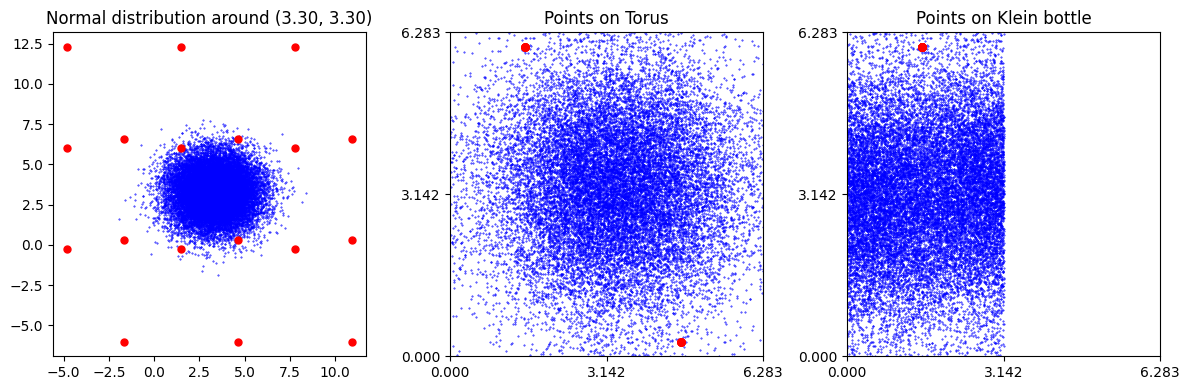

In [3]:
xs, ys = p_plane[:,0], p_plane[:,1]
xs_fold = np.remainder(xs, 2 * np.pi)
ys_fold = np.remainder(ys, 2 * np.pi)
points_folded = np.array([xs_fold, ys_fold]).T
#print(points_folded)

# Plot the folded points on the Klein bottle
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title(f'Normal distribution around ({mean[0]:.2f}, {mean[1]:.2f})')

axes[1].plot(np.remainder(points[:,0], 2 * np.pi), np.remainder(points[:,1], 2 * np.pi), 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Torus')
axes[1].set_xlim(0, 2 * np.pi)
axes[1].set_ylim(0, 2 * np.pi)
axes[1].axes.get_xaxis().set_ticks([0, np.pi, 2 * np.pi])
axes[1].axes.get_yaxis().set_ticks([0, np.pi, 2 * np.pi])

axes[2].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[2].set_title('Points on Klein bottle')
axes[2].set_xlim(0, 2 * np.pi)
axes[2].set_ylim(0, 2 * np.pi)
axes[2].axes.get_xaxis().set_ticks([0, np.pi, 2 * np.pi])
axes[2].axes.get_yaxis().set_ticks([0, np.pi, 2 * np.pi])

# Choose a single point (e.g. the first one) to highlight
p_torus = points_folded
p_klein = project_klein(p_torus[:, 0], p_torus[:, 1])
#print(p_klein[:10])


# Plot in red on each subplot
axes[0].plot(p_plane[:,0], p_plane[:,1], 'ro', markersize=5)
axes[1].plot(p_torus[:,0], p_torus[:,1], 'ro', markersize=5)
#axes[1].plot(np.remainder(p_plane[0], 2 * np.pi), np.remainder(p_plane[1], 2 * np.pi), 'ko', markersize=5)
axes[2].plot(p_klein[:,0], p_klein[:,1], 'ro', markersize=5)

#! DEBUG

wrong_idx = np.where(~np.all(np.isclose(p_klein, [1.5, 6]), axis=1))[0]
wrong_plane_points = p_plane[wrong_idx]
wrong_torus_points = p_torus[wrong_idx]
print(f'Wrong plane points: {wrong_plane_points}')

axes[0].plot(wrong_plane_points[:,0], wrong_plane_points[:,1], 'go', markersize=5)
axes[1].plot(wrong_torus_points[:,0], wrong_torus_points[:,1], 'go', markersize=5)
axes[2].plot(p_klein[wrong_idx, 0], p_klein[wrong_idx, 1], 'go', markersize=5)

plt.tight_layout()
plt.show()

In [30]:
from typing import Callable

def projection_onto_a_line(theta: float) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Creates a function that projects a point onto a line.
    """
    return lambda x,y: (x * np.cos(theta) + y * np.sin(theta))
    

def chebyshev_2(t: float) -> float:
    """
    Chebyshev polynomial of the 2nd degree.
    """
    return 2 * t**2 - 1


def klein_filter(theta_1: float, theta_2: float) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Klein filter for given angles theta_1 and theta_2.
    """
    t = projection_onto_a_line(theta_1)
    return lambda x,y: np.sin(theta_2) * t(x,y) + np.cos(theta_2) * chebyshev_2(t(x,y))

def generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True) -> np.ndarray:
    """
    Generate a Klein filter matrix of given size for specified angles.

    Parameters:
    - theta_1: Angle for the first projection.
    - theta_2: Angle for the second projection.
    - size: Size of the matrix.
    - midpoint: If True, use midpoints for the grid; otherwise, use edges.
    """
    f = klein_filter(theta_1, theta_2)
    coords = np.linspace(-1 + 1/size, 1 - 1/size, size) if midpoint else np.linspace(-1, 1, size)
    X, Y = np.meshgrid(coords, coords)
    Z = f(X, Y)
    return Z

thetas_1: [0.         0.31415927 0.62831853 0.9424778  1.25663706 1.57079633
 1.88495559 2.19911486 2.51327412 2.82743339 3.14159265]
thetas_2: [0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
 3.76991118 4.39822972 5.02654825 5.65486678 6.28318531]
thetas_1: [0.         0.31415927 0.62831853 0.9424778  1.25663706 1.57079633
 1.88495559 2.19911486 2.51327412 2.82743339 0.        ]
thetas_2: [0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
 3.76991118 4.39822972 5.02654825 5.65486678 0.        ]


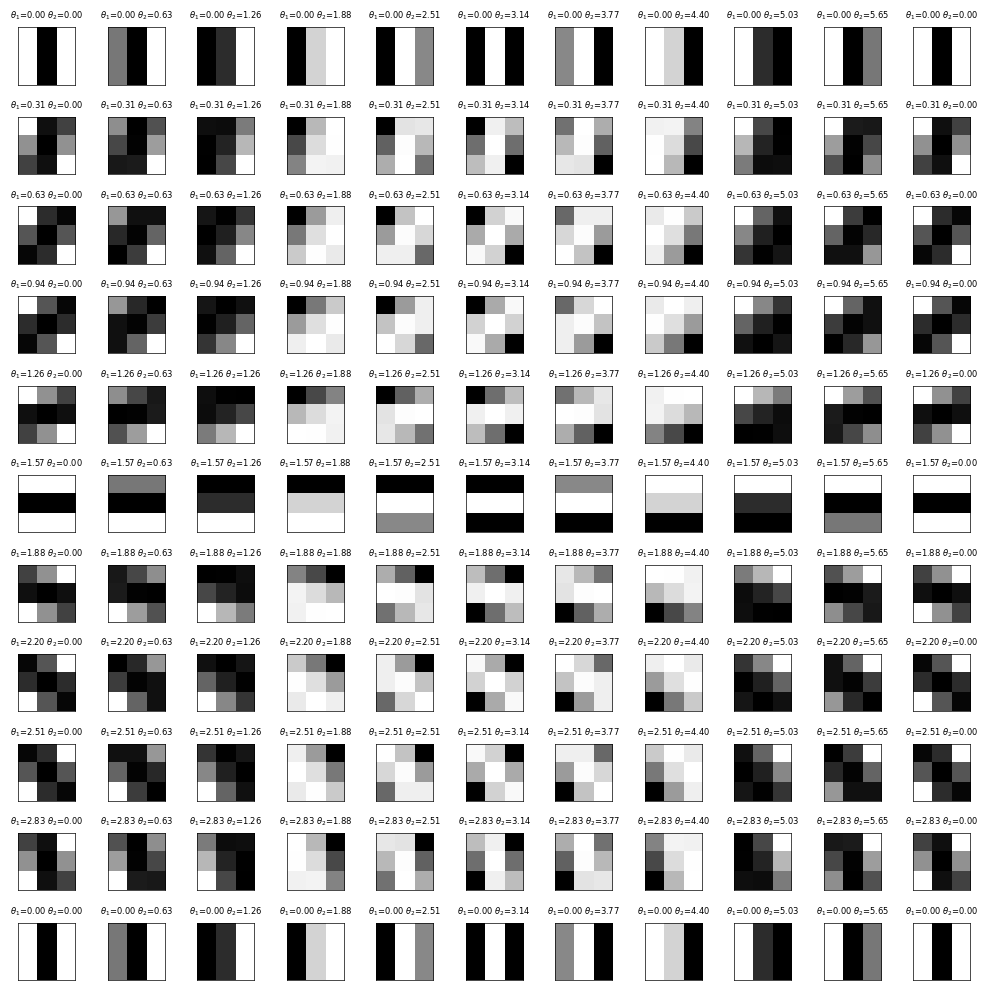

In [31]:
n = 10
thetas_1 = np.linspace(0, np.pi, n+1)
thetas_2 = np.linspace(0, 2 * np.pi, n+1)
print(f"thetas_1: {thetas_1}")
print(f"thetas_2: {thetas_2}")
points_on_klein = project_klein(thetas_1, thetas_2)
thetas_1 = points_on_klein[:, 0]
thetas_2 = points_on_klein[:, 1]
print(f"thetas_1: {thetas_1}")
print(f"thetas_2: {thetas_2}")


fig, axes = plt.subplots(n+1, n+1, figsize=(10, 10))
for i in range(0, n+1):
    for j in range(0, n+1):
        # Use projection_on_klein to get (theta_1, theta_2)
        theta_1 = thetas_1[i]
        theta_2 = thetas_2[j]
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        axes[i, j].imshow(filter_img, cmap='gray', extent=[-1, 1, -1, 1])
        axes[i, j].set_title(f"$\\theta_1$={theta_1:.2f}\t$\\theta_2$={theta_2:.2f}", fontsize=6)
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import multivariate_normal

point = np.random.multivariate_normal(mean=np.array([0.75, 0.75]),
                                       cov=np.array([[0.12, 0], [0, 0.12]]),
                                       size=1)

mean = np.array([0.75, 0.75])
cov = np.array([[0.12, 0], [0, 0.12]])
log_prob = multivariate_normal(mean=mean, cov=cov).logpdf(point[0])
print("log_prob:", log_prob)
print("prob:", np.exp(log_prob))

x, y = np.mgrid[0:1.5:0.01, 0:1.5:0.01]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
plt.figure(figsize=(6, 5))
plt.contourf(x, y, rv.pdf(pos), levels=30, cmap='viridis')
plt.scatter(point[0, 0], point[0, 1], color='red', s=60, label='Sampled point')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Probability Density with Sampled Point')
plt.legend()
plt.show()